# Gradient Descent - Multiple Linear Regression

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# generating sythetic datasets
from sklearn.datasets import make_regression
x,y = make_regression(n_samples = 1000, n_targets = 1, n_features = 3, n_informative = 3, noise = 10)

In [21]:
print(x.shape)
print(y.shape)

(1000, 3)
(1000,)


In [22]:
# converting to dataframe
df = pd.DataFrame({
    'feature1':x[:,0],
    'feature2':x[:,1],
    'target':y
})
df.head()

,feature1,feature2,target
0,-0.397510,-0.470422,85.559652
1,0.481627,0.593923,81.420114
2,-0.821333,-1.380228,-78.668590
3,0.124467,1.680414,-33.286519
4,0.926854,-0.065763,19.181599


In [23]:
# plot of existing data
import plotly.express as px
fig = px.scatter_3d(df,x = 'feature1', y = 'feature2', z = 'target', color = 'target')
fig

In [24]:
# sklearn linearRegression for comparison
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 2)

In [25]:
# model training
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [26]:
# predicitons
y_pred = lr.predict(x_test)

In [27]:
# evaluation
from sklearn.metrics import r2_score
r2_score_lr =  r2_score(y_test, y_pred)
r2_score_lr

0.987176058897635

In [28]:
print(lr.coef_) # b1 - b3
print(lr.intercept_)  # b0

[33.99196576 27.5478918  71.19674468]
0.40590856519800234


# Custom class - Batch Gradient Descent

In [29]:
class batch_gd:
  def __init__(self, learning_rate, epochs):
    self.n = learning_rate
    self.epochs = epochs
    self.coef_ = None
    self.intercept_ = None
    self.loss_list = []

  def fit(self, x_train, y_train):
    # Initialize intercept and coefficients
    self.intercept_ = 0
    # Initialize coef_ with shape (n_features,)
    self.coef_ = np.ones(x_train.shape[1])

    for i in range(self.epochs):

      # Calculate predictions
      y_pred = self.intercept_ + np.dot(x_train, self.coef_)

      # Calculate gradients
      grad_intercept = (-2 / x_train.shape[0]) * np.sum(y_train - y_pred)
      # Corrected: Use np.dot for proper vector-matrix multiplication
      grad_coef = (-2/x_train.shape[0]) * np.dot((y_train - y_pred), x_train)

      # Update parameters
      self.intercept_ -= (self.n * grad_intercept)
      self.coef_ -= (self.n * grad_coef)

      # Calculate loss
      loss = np.mean((y_train - y_pred)**2)
      self.loss_list.append(loss) # Corrected: Append loss to list

      print(f'step {i} | loss = {loss}')

    print('final ✅')
    print('coef_ = ', self.coef_)
    print('intercept_ = ', self.intercept_)

  def predict(self, x_test):
    return self.intercept_ + np.dot(x_test, self.coef_)

In [30]:
# model training
gd = batch_gd(0.01, 1000)
gd.fit(x_train, y_train)

step 0 | loss = 6384.392624721115
step 1 | loss = 6150.887143502943
step 2 | loss = 5926.092282184808
step 3 | loss = 5709.681759012028
step 4 | loss = 5501.341569871546
step 5 | loss = 5300.769523986636
step 6 | loss = 5107.674797265591
step 7 | loss = 4921.777502629244
step 8 | loss = 4742.808276668159
step 9 | loss = 4570.507882005257
step 10 | loss = 4404.626824763702
step 11 | loss = 4244.924986562921
step 12 | loss = 4091.171270487818
step 13 | loss = 3943.143260497585
step 14 | loss = 3800.626893760987
step 15 | loss = 3663.416145424752
step 16 | loss = 3531.3127253405833
step 17 | loss = 3404.1257862945868
step 18 | loss = 3281.671643300372
step 19 | loss = 3163.773503533951
step 20 | loss = 3050.2612065047183
step 21 | loss = 2940.97097407238
step 22 | loss = 2835.7451699346384
step 23 | loss = 2734.4320682248303
step 24 | loss = 2636.8856308725462
step 25 | loss = 2542.9652933935486
step 26 | loss = 2452.5357587880835
step 27 | loss = 2365.4667992389855
step 28 | loss = 2281.

In [31]:
y_pred_gd = gd.predict(x_test)

In [32]:
print(lr.coef_)
print(lr.intercept_)

[33.99196576 27.5478918  71.19674468]
0.40590856519800234


In [33]:
# R2_score for GD
r2_gd = r2_score(y_test, y_pred_gd)
r2_gd

0.9871760592509323

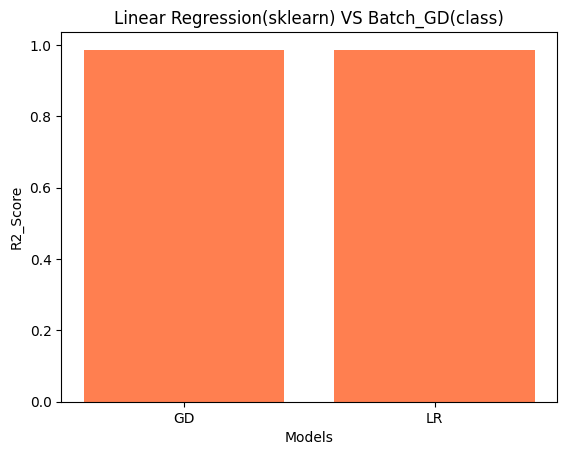

In [34]:
# bar plot for comparing both R2_Scores
data = {
    'GD':r2_gd,
    'LR':r2_score_lr
}

plt.bar(data.keys(), data.values(), color = 'coral')
plt.xlabel('Models')
plt.ylabel('R2_Score')
plt.title('Linear Regression(sklearn) VS Batch_GD(class)')
plt.show()